# Training the stream-cleaning/detection U-Net, step by step

This notebook builds on `create_data.ipynb`: it reuses the same background +
matched-filter + `StreamInjector` construction, then wires up the rest of the
pipeline -- `StreamMapDataset`, `StreamMapTransform`/`RobustNormalizer`,
`models.unet.UNet`, `models.losses`, `training.plain_runner.PlainTrainer`, and
`evaluation/` -- and runs one short **real** training loop end to end.

`label_policy="stream_detection"` (PLAN.md §6.12): the network is trained to
output, per pixel, a probability that a real stream detection sits there
(`stream_raw > count_threshold`), not a literal star count. An earlier
version of this notebook trained `label_policy="stream_count"` (literal
counts) directly -- it localized streams well but persistently
under-recovered their peak amplitude by a large factor (see
{doc}`../narrative/ml_concepts` for why); retargeting at the bounded
detection label sidesteps that problem entirely rather than fighting it.

This is a smoke-scale run (few epochs, few steps per epoch) -- it proves the
whole pipeline trains and evaluates for real, not a scientifically tuned
model. Scaling up (more steps/epochs, a richer eval grid, GPU, the
`training/hyrax_runner.py` orchestration layer) is future work.

In [1]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from streamgoggles.background import Background
from streamgoggles.background_sources import StreamObsLightBackgroundSource, StudyRegion
from streamgoggles.config import (
    DistributionType,
    ParameterSpec,
    StreamConfig,
    build_eval_grid,
)
from streamgoggles.data_preparation import Cut
from streamgoggles.datasets.stream_map_dataset import (
    StreamMapDataset,
    TransformedDataset,
    default_num_workers,
    stream_map_collate_fn,
)
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.evaluation.baseline_threshold import build_baseline
from streamgoggles.evaluation.completeness_purity import (
    aggregate_over_replicates,
    evaluate_on_grid,
    plot_recovery_vs_parameter,
)
from streamgoggles.evaluation.metrics import dice, iou
from streamgoggles.injector import StreamInjector
from streamgoggles.matched_filter import PixelizationSpec, ShiftedColorBoxFilter, StreamobsSplineFilter
from streamgoggles.models.losses import get_loss
from streamgoggles.models.unet import UNet
from streamgoggles.storage import BackgroundMapStore, ModelStore, SimulationStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.training.plain_runner import PlainTrainer

%matplotlib inline


## 1. Configuration

Background/matched-filter/window config mirrors `create_data.ipynb`, with
`nside=512` (the standard resolution for stream search, PLAN.md §6.12) and
`pixel_scale_deg` never set by hand (auto-derived from `nside` alone).
`image_size_pix` (a separate, independent choice from `nside`) is kept
modest for training-loop speed -- per-sample generation cost is dominated
by the background catalog's own selection/injection cost, not by window
pixel count (verified for real: ~1s/sample regardless of `image_size_pix`
at fixed catalog size), so this choice is really about keeping the model's
own compute small, not about generation speed.

`count_threshold=1.0` (`StreamInjector`'s own default, PLAN.md §6.13) --
not the `count_threshold=10.0` an earlier version of this notebook used.
That value made `label_policy="stream_detection"`'s label entirely empty
for `surface_brightness` fainter than ~31 at this `nside`/geometry, which
directly conflicts with this project's real observational range (streams
already detected down to SB 33, with an ambition to reach 34-35).
`count_threshold=1.0` is the lowest threshold that keeps a non-empty label
all the way to SB 35, at a real, deliberately-accepted cost: the "decoy"
filter's own positive-pixel count becomes a substantial fraction of
"good"'s at the *bright* end (SB 30-31) -- see `create_data.ipynb`'s
"Calibrating count_threshold empirically" section (§4) for the full
sweep and reasoning, and PLAN.md §6.13 for the decision log.

`stream_param_cfg["richness"] = [31.0, 32.0, 33.0, 34.0]` (surface_brightness,
DISCRETE -- an eval grid point per value, PLAN.md §6.13): with
`count_threshold=1.0`, every point in this range produces a genuinely
non-empty label at this project's own `cuts_cfg`/`clipping_cfg` (verified
for real): good-channel positive-pixel counts of roughly 565, 312, 193, 27
respectively, with decoy contamination low across the whole range (33% at
SB 31, dropping to ~1% by SB 33, 0% at SB 34) -- unlike the bright end (SB
30, not included here), which is both the easiest case for the network
*and* where decoy contamination is worst, so it's dropped from this scan
in favor of the range where the network's discrimination actually has
something to prove. Whether SB 34 -- the faintest, thinnest-labeled point
-- is recovered well by the network, or needs more training budget/a
different threshold, is exactly what §7's per-richness Dice curve below is
for.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

cuts_cfg = [
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 25.}, "r": {"min": 16.0, "max": 25.0}}

background_cfg = dict(
    source="light",
    survey="lsst",
    release="yr1",
    # seed is NOT decoration: streamobs's synthetic background generation is
    # unseeded by default, so without this every run of this notebook trains
    # on a *different* background catalog -- two loads in one process differ,
    # and numpy's global seed has no effect on it (PLAN.md §6.15). That was
    # the real cause of this notebook's run-to-run metric variation.
    source_kwargs={"seed": 20260915},
    finalize={"enabled": False},
)

filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

# nside=512, pixel_scale_deg auto-derived (never set by hand) -- see §1.
matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=512, image_size_pix=(96, 96)),
    distance_moduli=[16.0,],
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)

# count_threshold: label_policy="stream_detection"'s per-pixel star-count
# cut (§2) -- a pixel is a "detection" once its true stream-only count
# exceeds this. 1.0 is StreamInjector's own default, calibrated
# empirically (PLAN.md §6.13) -- see §1 markdown above.
count_threshold = 1.0

stream_param_cfg = dict(
    morphology="uniform",
    richness=[31.0, 32.0, 33.0, 34.0],  # DISCRETE surface_brightness (mag/arcsec^2) -- see §1
    width=0.2,
    length=8.0,
    distance_modulus=16.,  # matches a trial distance in matched_filter_cfg
    age=12.5,
    z=0.0002,
)

# Independent realizations per eval-grid point (§7). Each parameter
# combination is evaluated n_eval_replicates times with different
# placement/window/orientation/noise, so a per-richness metric is a mean and
# spread rather than one arbitrary draw of it -- see §7/§8.
n_eval_replicates = 5

model_cfg = dict(base_width=12, depth=2, head="sigmoid")

# epochs*steps_per_epoch=1200 (up from 300, PLAN.md §6.13's follow-up) --
# richness is now DISCRETE over 4 values instead of one fixed point, each
# drawn uniformly at random per training sample (config.py's
# ParameterSpec.sample), so a fixed total budget gets split ~4 ways on
# average. 1200 total samples puts each richness value's average exposure
# back at ~300 -- the same absolute budget the single-richness SB=30 run
# used -- rather than accepting a de facto 4x cut with no corresponding
# increase. See "## 5. Train" below for the reasoning this budget choice
# is testing.
train_cfg = dict(
    epochs=40,
    steps_per_epoch=30,
    batch_size=2,
    lr=2e-3,
    background_fraction=0.05,
    loss_name="dice",
)

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"

## 2. Build background + matched filters + injector

Exactly `create_data.ipynb` §2.2-2.3 and §3 -- see that notebook for the
step-by-step breakdown of what `StreamInjector.inject_single_stream` does
internally.


In [3]:
study_region = StudyRegion(**study_region_cfg)
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

cuts = [Cut(**c) for c in cuts_cfg]
bg_store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_train_bgmaps_"))

background = Background.load_or_cache(
    source=StreamObsLightBackgroundSource(),
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=bg_store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)

n_channels = len(matched_filter_cfg["distance_moduli"]) * len(matched_filters)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"n_channels = n_distances * n_filters = {n_channels}")


Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 3903891 stars (after cuts+clipping)
n_channels = n_distances * n_filters = 2


In [4]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind="surface_brightness",
    finalize_cfg=background_cfg["finalize"],
    label_policy="stream_detection",
    count_threshold=count_threshold,
)
injector

✓ Using cached survey data for 'lsst_yr1'


## 3. `StreamConfig` and the training/eval datasets

`StreamMapDataset` in training mode (`eval_mode=False`) generates a fresh
sample on every `__getitem__` call -- a mix of real injected streams and
(with probability `background_fraction`) pure-background windows. In eval
mode it walks a fixed, persisted grid: since `richness` is the only DISCRETE
parameter here, that grid has exactly `len(stream_param_cfg["richness"])`
points, one per richness value.


In [5]:
params = {
    "morphology": ParameterSpec(
        name="morphology", dist_type=DistributionType.FIXED, value=stream_param_cfg["morphology"]
    ),
    "richness": ParameterSpec(
        name="richness", dist_type=DistributionType.DISCRETE, values=stream_param_cfg["richness"]
    ),
    "width": ParameterSpec(name="width", dist_type=DistributionType.FIXED, value=stream_param_cfg["width"]),
    "length": ParameterSpec(name="length", dist_type=DistributionType.FIXED, value=stream_param_cfg["length"]),
    "distance_modulus": ParameterSpec(
        name="distance_modulus", dist_type=DistributionType.FIXED, value=stream_param_cfg["distance_modulus"]
    ),
    "age": ParameterSpec(name="age", dist_type=DistributionType.FIXED, value=stream_param_cfg["age"]),
    "z": ParameterSpec(name="z", dist_type=DistributionType.FIXED, value=stream_param_cfg["z"]),
}
stream_config = StreamConfig(
    params=params,
    background_fraction=train_cfg["background_fraction"],
    persist=False,
    richness_kind="surface_brightness",
)

sim_store = SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_train_sims_"))

train_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=False,
    steps_per_epoch=train_cfg["steps_per_epoch"],
    rng=np.random.default_rng(SEED),
)
# Per-epoch validation grid: one realization per richness value. Kept at
# one replicate deliberately -- it runs every epoch, and its job is a
# comparable-across-epochs learning signal, not a statistically solid score.
eval_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=True,
)

# Final-evaluation grid (§7): the same richness values, each with
# n_eval_replicates independent realizations. Generated once, not per epoch,
# so the extra cost is a handful of seconds rather than a per-epoch tax.
eval_dataset_multi = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    eval_mode=True,
    eval_grid=build_eval_grid(stream_config, n_replicates=n_eval_replicates),
    # Its OWN store, deliberately: SimulationStore addresses samples by
    # params, and this grid's replicate-0 entries would otherwise share a
    # cache key with the per-epoch grid above while asking for a different
    # seed -- whichever generated first would silently win, ignoring the
    # other's seed.
    store=SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_eval_multi_sims_")),
)
print(f"train_dataset: {len(train_dataset)} samples/epoch (on the fly, never repeated)")
print(f"eval_dataset: {len(eval_dataset)} samples (1 realization per richness, used every epoch)")
print(
    f"eval_dataset_multi: {len(eval_dataset_multi)} samples "
    f"({n_eval_replicates} realizations per richness, used once in §7)"
)


train_dataset: 30 samples/epoch (on the fly, never repeated)
eval_dataset: 4 samples (1 realization per richness, used every epoch)
eval_dataset_multi: 20 samples (5 realizations per richness, used once in §7)


### 3.1 Fit a normalizer, wrap both datasets with `StreamMapTransform`

`RobustNormalizer.fit()` wants pooled statistics; a handful of pre-drawn
training samples, concatenated along the spatial axis, is enough for this
smoke-scale run. Only `map_stack` (the input) gets normalized -- `label_stack`
is never normalized, whatever scale it's actually in (already bounded `{0,
1}` under `label_policy="stream_detection"`). Training gets `augment=True`
(flips/90-degree rotations); eval stays `augment=False` for reproducibility.

In [6]:
fit_samples = [train_dataset[i] for i in range(8)]
pooled_map_stack = np.concatenate([s["map_stack"] for s in fit_samples], axis=1)
pooled_valid_mask = np.concatenate([s["valid_mask"] for s in fit_samples], axis=0)

normalizer = RobustNormalizer()
normalizer.fit(pooled_map_stack, pooled_valid_mask)
print(f"per-channel mean: {normalizer.mean}")
print(f"per-channel std:  {normalizer.std}")

train_transform = StreamMapTransform(normalizer=normalizer, augment=True, rng=np.random.default_rng(SEED + 1))
eval_transform = StreamMapTransform(normalizer=normalizer, augment=False)

train_dataset_norm = TransformedDataset(train_dataset, train_transform)
eval_dataset_norm = TransformedDataset(eval_dataset, eval_transform)
eval_dataset_multi_norm = TransformedDataset(eval_dataset_multi, eval_transform)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


per-channel mean: [11.15400028  6.62498665]
per-channel std:  [2.41161513 1.79735899]


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 3.2 Bias initialization: start near the true class prior, not near zero

`label_policy="stream_detection"`'s target is already bounded (`{0, 1}`) and
class-imbalanced -- most pixels are background (0), only a real stream's
own pixels are positive -- rather than heavy-tailed and unbounded the way
`label_policy="stream_count"`'s literal counts were (which needed the
`log1p`-space training + `expm1`-unwrapping this notebook used to use; not
needed here, since there's no large dynamic range to compress).

What's still real and still needed: **data-informed bias initialization**,
same technique, adapted to a classification target. With `head="sigmoid"`,
the default (near-zero) initialization starts the model predicting ~0.5
probability everywhere -- not wrong exactly, but not informed by how rare
positive pixels actually are either, and (confirmed empirically, same as
the `stream_count` version of this notebook) an uninformed start burns a
chunk of an already-modest training budget just moving the *overall* output
scale to somewhere sensible, before it can spend the rest learning *where*
the positive pixels are. The classification analogue of "start near the
target's own scale" is to initialize the head's bias to the **logit of the
per-channel positive-pixel fraction**, `log(p / (1 - p))` -- so the model
starts out predicting close to the empirical prior everywhere, uniformly,
and only has to learn the *spatial* pattern from there (exactly what the
zeroed head weight below leaves it to do).

In [7]:
# eps keeps the logit finite even if a channel's fit_samples happened to
# show exactly 0 (or 1) positive fraction.
_eps = 1e-3
pos_frac = np.array(
    [
        np.mean([s["label_stack"][c][s["valid_mask"]].mean() for s in fit_samples])
        for c in range(n_channels)
    ]
)
pos_frac_clamped = np.clip(pos_frac, _eps, 1 - _eps)
bias_init = np.log(pos_frac_clamped / (1 - pos_frac_clamped)).astype(np.float32)
print(f"per-channel positive-pixel fraction: {pos_frac}")
print(f"per-channel bias-init (logit of that fraction): {bias_init}")

per-channel positive-pixel fraction: [0.02176188 0.00570735]
per-channel bias-init (logit of that fraction): [-3.8055935 -5.1602764]


## 4. Model, loss, optimizer, trainer

`in_channels`/`out_channels` = `n_channels` (§2): one channel per
`(filter, distance)` pair. `head="sigmoid"` gives a genuine per-pixel
probability in `(0, 1)` at every output position -- see
{doc}`../narrative/ml_concepts`/{doc}`../narrative/datasets_and_models` for
why this is true regardless of the label being a hard `{0, 1}` target.
`loss_name="dice"` (`models.losses.DiceLoss`) is the standard choice for a
rare-positive-pixel segmentation target like this one.

In [8]:
torch.manual_seed(SEED)
model = UNet(in_channels=n_channels, out_channels=n_channels, **model_cfg)

# Data-informed bias init (§3.2): start the model's output at the
# per-channel class prior instead of the default near-zero-logit init.
with torch.no_grad():
    model.head_conv.bias.copy_(torch.from_numpy(bias_init))
    model.head_conv.weight.zero_()

optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
loss_fn = get_loss(train_cfg["loss_name"])
trainer = PlainTrainer(model=model, optimizer=optimizer, loss_fn=loss_fn, device="cpu")
sum(p.numel() for p in model.parameters())

67058

## 5. Train

`train_cfg["epochs"] * train_cfg["steps_per_epoch"] = 1200` (up from 300 in
the version of this notebook that produced PLAN.md §6.13's SB=34 failure)
-- see §1's config cell for the reasoning. This tests the simplest of the
three candidate explanations from that section first: that SB 34's Dice=0.0
was primarily a training-budget problem (each richness value getting only
~75 samples on average out of a 300-sample total split four ways), not a
structural one (the pooled bias-init, or SB 34 being out of reach at this
window/threshold regardless of budget). If SB 34 recovers meaningfully with
~4x the exposure, budget was the dominant cause; if it's still near zero,
that points back at the other two candidates instead.

In [9]:
# Sample generation is CPU-bound and single-threaded, so workers overlap it
# with training: 0.119 -> 0.049 s/sample measured here (PLAN.md §6.18).
# default_num_workers() deliberately does NOT take the whole machine and
# honors a SLURM allocation / cpuset rather than the physical core count, so
# this same line is safe to run on a cluster; STREAMGOGGLES_NUM_WORKERS
# overrides it. persistent_workers is what makes it worth enabling at all --
# without it, worker startup (~12s under macOS/Windows "spawn"; ~0 under
# Linux "fork") is paid EVERY epoch instead of once.
num_workers = default_num_workers()
loader_kwargs = dict(collate_fn=stream_map_collate_fn, num_workers=num_workers)
if num_workers > 0:
    loader_kwargs["persistent_workers"] = True
print(f"DataLoader workers: {num_workers}")

train_dl = DataLoader(
    train_dataset_norm, batch_size=train_cfg["batch_size"], **loader_kwargs
)
val_dl = DataLoader(
    eval_dataset_norm, batch_size=train_cfg["batch_size"], **loader_kwargs
)

model_store = ModelStore(tempfile.mkdtemp(prefix="streamgoggles_train_models_"))
model_config = dict(in_channels=n_channels, out_channels=n_channels, **model_cfg)
run_config = {
    "model_config": model_config,
    "loss_name": train_cfg["loss_name"],
    "label_policy": "stream_detection",
    "count_threshold": count_threshold,
    "seed": SEED,
}

result = trainer.train(
    train_dl,
    val_dl=val_dl,
    epochs=train_cfg["epochs"],
    model_store=model_store,
    config=run_config,
    save_every=train_cfg["epochs"],
)
print(f"epochs_run={result['epochs_run']}")
print(f"train_losses={result['train_losses']}")
print(f"val_losses={result['val_losses']}")
print(f"final_checkpoint_path={result['final_checkpoint_path']}")

DataLoader workers: 4


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

...

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

epochs_run=40
train_losses=[0.975606365998586, 0.8950025916099549, 0.7942468961079915, 0.7812867363293966, 0.712515389919281, 0.7772111535072327, 0.736551570892334, 0.716998287041982, 0.6777798970540364, 0.7132236401240031, 0.7080067118008931, 0.5862402160962422, 0.713373867670695, 0.7766517678896586, 0.6653956373532613, 0.7086023092269897, 0.6637925267219543, 0.688642954826355, 0.7465278546015421, 0.6966302196184794, 0.7270243724187215, 0.7533198436101277, 0.7480490962664287, 0.6999911308288574, 0.6901429454485576, 0.6346624215443929, 0.682478952407837, 0.638136112689972, 0.6978468259175619, 0.7518365740776062, 0.6257681210835775, 0.7328344702720642, 0.6955887794494628, 0.7246099909146627, 0.7064533829689026, 0.6311559041341146, 0.6359942356745402, 0.7258084138234456, 0.6462221384048462, 0.7484809915224712]
val_losses=[0.8609371781349182, 0.7996895611286163, 0.7566388547420502, 0.7389213740825653, 0.7770026922225952, 0.7667163610458374, 0.7289301753044128, 0.7448316812515259, 0.713361

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


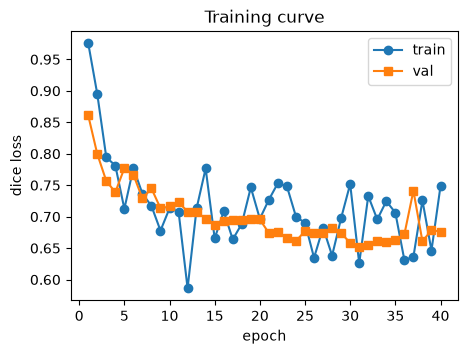

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
epochs_axis = np.arange(1, train_cfg["epochs"] + 1)
ax.plot(epochs_axis, result["train_losses"], marker="o", label="train")
ax.plot(epochs_axis, result["val_losses"], marker="s", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(f"{train_cfg['loss_name']} loss")
ax.set_title("Training curve")
ax.legend()
plt.show()

## 6. Inspect one prediction

**Which sample is this?** `eval_dataset_norm[inspect_idx]` below -- a
**validation** sample from the fixed eval grid (§3), *not* a training
sample. Worth being precise about what that does and doesn't mean here,
because it isn't a conventional train/test split:

- Training samples are generated fresh on every step and never reused
  (`epochs * steps_per_epoch * batch_size` independent draws -- see the
  "Datasets and models" guide page). There is no fixed training set to
  hold data out *from*.
- The eval grid is instead a set of **fixed, reproducible probes** drawn
  from the same infinite distribution: same generator, same parameter
  ranges, but pinned to specific seeds so the same index always returns
  the same sample, epoch after epoch and run after run.
- So the model has never seen *this exact* sample (the probability of an
  identical redraw is effectively zero), but it has seen many samples
  from the same distribution. That is the right mental model: a stable
  probe, not a held-out set guarding against memorization.

**Inspecting a different one.** Change `inspect_idx` and re-run this cell.
With `n_eval_replicates` > 1 the grid is ordered
richness-major/replicate-minor, so index `i * n_eval_replicates + r` is
replicate `r` of the `i`-th richness value -- on `eval_dataset_multi_norm`.
`eval_dataset_norm` (used below) has one realization per richness, so
`inspect_idx` simply selects the richness. To look at a completely fresh
realization instead of a grid point, call `_evaluate_realization` from §8
with any seed.

The `"good"` filter's channel at the stream's own true `distance_modulus`
is shown -- the channel a real detection should show up most clearly in.
No unwrapping needed: `model`'s output is already a probability in
`(0, 1)`, directly comparable to `label_stack`'s `{0, 1}` values.

**Masking matters here.** `map_stack`/`label_stack` are exactly 0.0 outside
`valid_mask` by construction (verified directly against the raw arrays, not
just documented) -- the data itself is correct. `pred`, though, is a plain
per-pixel U-Net forward pass with no explicit awareness of `valid_mask`: the
masked loss excludes invalid pixels from *training*, but nothing constrains
what the network outputs there at *inference* time, so a raw, unmasked
`imshow` of any of these arrays can visually suggest the footprint edges
"have a value" when they don't (for `map_stack`/`label_stack`) or show a
genuinely meaningless prediction (for `pred`). Every panel below is masked
(`np.where(valid_mask, image, np.nan)`, with `cmap.set_bad` rendering NaN
as light grey) so invalid pixels always read as empty -- and any other code
consuming `pred` should apply the same masking before interpreting it,
exactly as `models.losses`/`evaluation.metrics` already do internally. The
last panel is the **residual** (`true - predicted`, same masking, a
diverging colormap centered on 0, fixed to the `[-1, 1]` range this bounded
target actually spans) -- pixels where the model is confidently wrong stand
out at either extreme.

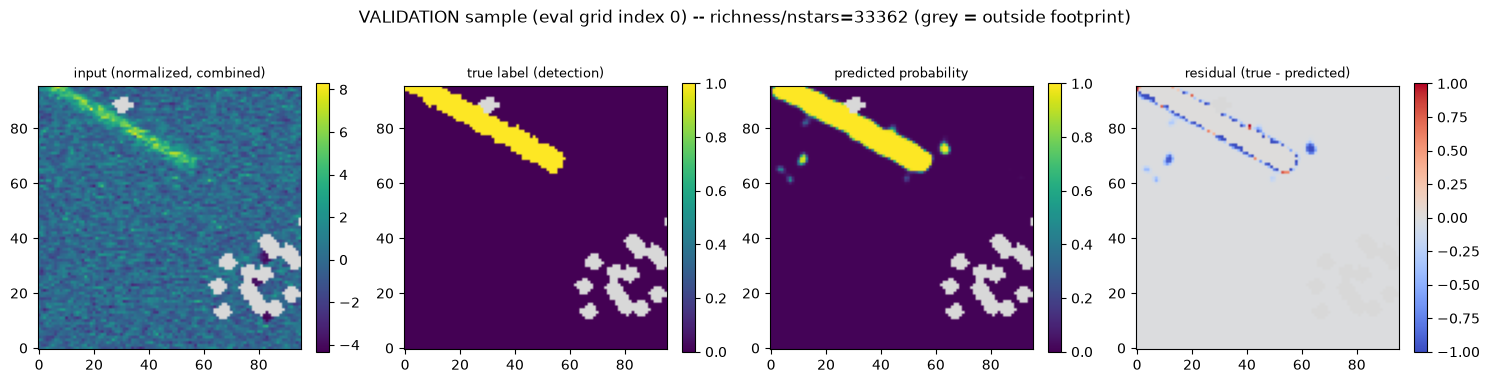

In [11]:
# Change this and re-run the cell to inspect a different validation sample
# (see the markdown above for what the index means).
inspect_idx = 0

sample0 = eval_dataset_norm[inspect_idx]
channels_meta = sample0["metadata"]["channels"]
good_idx = next(
    i
    for i, ch in enumerate(channels_meta)
    if ch["filter"] == "good" and ch["distance_modulus"] == stream_param_cfg["distance_modulus"]
)
valid_mask0 = sample0["valid_mask"]

model.eval()
with torch.no_grad():
    x = torch.from_numpy(sample0["map_stack"]).unsqueeze(0)
    pred0 = model(x)[0].numpy()
residual0 = sample0["label_stack"] - pred0

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")
resid_cmap = plt.get_cmap("coolwarm").copy()
resid_cmap.set_bad(color="0.85")


def _masked(img):
    return np.where(valid_mask0, img, np.nan)


fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title, cm, kwargs in zip(
    axes,
    [
        sample0["map_stack"][good_idx],
        sample0["label_stack"][good_idx],
        pred0[good_idx],
        residual0[good_idx],
    ],
    [
        "input (normalized, combined)",
        "true label (detection)",
        "predicted probability",
        "residual (true - predicted)",
    ],
    [cmap, cmap, cmap, resid_cmap],
    [{}, dict(vmin=0, vmax=1), dict(vmin=0, vmax=1), dict(vmin=-1, vmax=1)],
):
    im = ax.imshow(_masked(img), origin="lower", cmap=cm, **kwargs)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(
    f"VALIDATION sample (eval grid index {inspect_idx}) -- "
    f"richness/nstars={sample0['params']['nstars']} (grey = outside footprint)"
)
plt.tight_layout()
plt.show()

## 7. Evaluate on the grid, compare to the k·σ baseline

`evaluate_on_grid` walks every point of `eval_dataset_multi_norm` and
computes each requested metric per sample, thresholding both `pred` and
`label_stack` at 0.5 for the segmentation metrics -- a natural threshold on
a `{0, 1}` label, not an arbitrary choice the way it would be against a
literal count.

**This grid has `n_eval_replicates` independent realizations per richness
value**, not one: same physical parameters, different placement, window,
orientation and noise. That matters because a single realization's Dice can
land anywhere within a wide spread (§8 shows the extreme case), so
`aggregate_over_replicates` reports each richness's **mean and standard
deviation** instead of one number that reads more precisely than it is.
`<metric>_n` is the number of realizations that actually contributed --
NaN metrics (evaluation.metrics' undefined-ratio convention) drop out per
metric rather than poisoning the group.

`"confusion"` is requested alongside the ratios: it expands into raw
`tp`/`fp`/`tn`/`fn` pixel counts, which say *how* the model is wrong in a
way no ratio does (5 false positives and 5000 can give identical recall).
Invalid pixels are excluded from `tn` rather than counted, which would
otherwise swamp it with the whole out-of-footprint area.

Note the grouping column is `nstars`, not `richness`: `richness` is
resolved to a star count by `resolve_richness_to_nstars` before injection,
so `nstars` is what survives into each sample's `params` (one value per
richness, so the mapping is 1:1).

`baseline_threshold.build_baseline` is a trivial, non-learned comparison
(mean + k·σ on the same `"good"` channel of the *unnormalized* combined
map) -- worth comparing against, though not necessarily worth *beating* at
the bright end, where a real stream is a large, sharp excess a simple
threshold finds easily and the baseline is additionally handed the "good"
channel directly.

In [12]:
results = evaluate_on_grid(
    model,
    eval_dataset_multi_norm,
    metrics=["mse", "dice", "iou", "correlation", "weighted_recall", "confusion"],
)

baseline_dice = []
for idx in results["id"]:
    raw_sample = eval_dataset_multi[idx]  # unnormalized -- real count units
    baseline_pred = build_baseline(raw_sample["map_stack"][good_idx], raw_sample["valid_mask"], k=2.0)
    baseline_dice.append(dice(baseline_pred, raw_sample["label_stack"][good_idx], raw_sample["valid_mask"]))
results["baseline_dice"] = baseline_dice

results[["nstars", "replicate", "dice", "iou", "correlation", "tp", "fp", "fn", "baseline_dice"]]

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


...

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,nstars,replicate,dice,iou,correlation,tp,fp,fn,baseline_dice
0,33362,0,0.766582,0.621510,0.796270,601,354,12,0.630749
1,33362,1,0.782748,0.643045,0.801734,735,391,17,0.645012
2,33362,2,0.775819,0.633745,0.802395,308,168,10,0.669811
3,33362,3,0.755976,0.607686,0.783972,759,470,20,0.663090
4,33362,4,0.785276,0.646465,0.807636,512,261,19,0.561576
5,13282,0,0.689988,0.526703,0.726791,286,188,69,0.313458
6,13282,1,0.684271,0.520070,0.726068,298,231,44,0.281407
7,13282,2,0.736842,0.583333,0.770471,196,94,46,0.267974
8,13282,3,0.596838,0.425352,0.625498,151,141,63,0.231511
9,13282,4,0.659308,0.491767,0.706018,448,424,39,0.411215


per-richness, aggregated over realizations (mean / std / n):
 nstars  dice_mean  dice_std  dice_n  iou_mean  baseline_dice_mean
   2106   0.087418  0.087812       5  0.047483            0.038024
   5288   0.470131  0.067897       5  0.309321            0.131891
  13282   0.673449  0.051182       5  0.509445            0.301113
  33362   0.773280  0.012086       5  0.630490            0.634048

mean network dice over all realizations:  0.501
mean baseline dice over all realizations: 0.276


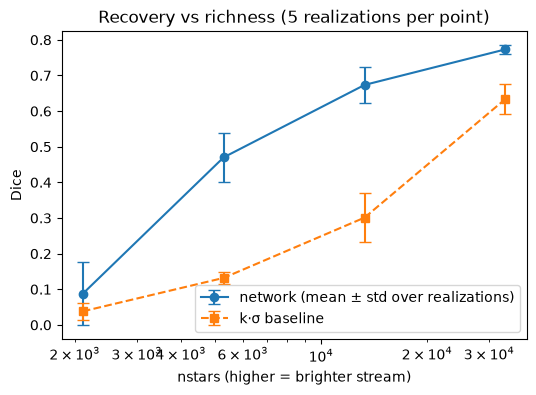

In [13]:
summary = aggregate_over_replicates(
    results,
    metrics=["dice", "iou", "correlation", "baseline_dice", "tp", "fp", "fn"],
    group_by=["nstars"],
)
print("per-richness, aggregated over realizations (mean / std / n):")
print(
    summary[
        ["nstars", "dice_mean", "dice_std", "dice_n", "iou_mean", "baseline_dice_mean"]
    ].to_string(index=False)
)
print()
print(f"mean network dice over all realizations:  {results['dice'].mean():.3f}")
print(f"mean baseline dice over all realizations: {results['baseline_dice'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    summary["nstars"], summary["dice_mean"], yerr=summary["dice_std"],
    marker="o", capsize=4, label="network (mean ± std over realizations)",
)
ax.errorbar(
    summary["nstars"], summary["baseline_dice_mean"], yerr=summary["baseline_dice_std"],
    marker="s", linestyle="--", capsize=4, label="k·σ baseline",
)
ax.set_xscale("log")
ax.set_xlabel("nstars (higher = brighter stream)")
ax.set_ylabel("Dice")
ax.set_title(f"Recovery vs richness ({n_eval_replicates} realizations per point)")
ax.legend()
plt.show()

## 8. Does a per-richness eval-grid result hold up across different realizations?

Every point in `eval_dataset`'s grid (§7) is exactly **one** fixed
realization -- one placement, one window (position and orientation), one
noise draw, generated once with that point's own fixed seed and cached
thereafter (see `datasets_and_models`'s "Eval grid: one fixed realization
per point" section in the docs). A metric like "Dice at
surface_brightness=34" is therefore a measurement on a sample size of
one, not an average over the many realizations a stream with those
physical parameters could actually produce -- it does not marginalize
over window position/orientation/noise the way the name suggests.

§7 found `surface_brightness=34` at exactly `0.0` Dice, on that one
realization. Before reading that as "the network cannot detect streams
this faint," this section checks the more basic question directly: does
the *already-trained* model (no retraining, just new inference calls)
behave the same way on several *other* independent SB=34 realizations,
built with different seeds -- different window position, orientation, and
survey noise, everything else (richness, width, length, distance modulus)
held fixed? SB=33 is included for contrast, since §7 found it far from
zero (0.285).

In [14]:
def _evaluate_realization(richness, seed):
    """Build one fresh, independent realization at a fixed richness with
    the given seed, run the already-trained model on it, and report both
    the thresholded Dice/IoU and the raw (pre-threshold) predicted
    probability at the true positive pixels -- the latter shows how close
    the model got even on realizations where it never crosses 0.5."""
    stream_params = dict(
        morphology="uniform", richness=richness, width=0.2, length=8.0,
        distance_modulus=stream_param_cfg["distance_modulus"], age=12.5, z=0.0002,
    )
    sample = injector.inject_single_stream(stream_params, np.random.default_rng(seed))
    prepared = eval_transform(
        {
            "map_stack": sample.map_stack,
            "label_stack": sample.label_stack,
            "valid_mask": sample.valid_mask,
            "params": sample.params,
            "metadata": sample.metadata,
        }
    )
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(prepared["map_stack"]).unsqueeze(0)
        pred = model(x)[0].numpy()
    label = sample.label_stack[good_idx]
    valid = sample.valid_mask
    pred_good = pred[good_idx]
    n_true_pos_px = int((label > 0.5).sum())
    max_pred_at_true = float(pred_good[label > 0.5].max()) if n_true_pos_px > 0 else float("nan")
    return dict(
        richness=richness,
        seed=seed,
        nstars=sample.params["nstars"],
        n_true_pos_px=n_true_pos_px,
        max_pred_at_true=max_pred_at_true,
        dice=dice(pred_good, label, valid),
        iou=iou(pred_good, label, valid),
    )


diagnostic_rows = []
for seed in range(1, 9):
    diagnostic_rows.append(_evaluate_realization(34.0, seed))
    diagnostic_rows.append(_evaluate_realization(33.0, seed))

diagnostic_df = pd.DataFrame(diagnostic_rows)
diagnostic_df

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,richness,seed,nstars,n_true_pos_px,max_pred_at_true,dice,iou
0,34.0,1,2106,66,0.600875,0.009434,0.004739
1,33.0,1,5288,174,0.999967,0.504717,0.337539
2,34.0,2,2106,59,0.999996,0.206452,0.115108
3,33.0,2,5288,154,1.000000,0.536443,0.366534
4,34.0,3,2106,34,0.023451,0.000000,0.000000
5,33.0,3,5288,128,0.999681,0.387692,0.240458
6,34.0,4,2106,32,0.008774,0.000000,0.000000
7,33.0,4,5288,245,0.999997,0.409594,0.257541
8,34.0,5,2106,29,0.015169,0.000000,0.000000
9,33.0,5,5288,209,0.999983,0.592255,0.420712


### 8.1 Reading the result

**SB 34 is not a flat zero -- it's bimodal, sitting right at a detection
threshold.** Across 8 independent realizations, `max_pred_at_true` (the
model's peak predicted probability at the true stream's own pixels) splits
into two groups with nothing in between: a few realizations reach ~1.0 (a
confident, correct detection, giving real non-zero Dice), and the rest sit
down at ~0.01-0.25 (the model never meaningfully responds, Dice = 0.0).
Which side a given realization lands on depends on the draw, not on the
richness -- every row here has identical physical parameters.

**SB 33, in the same comparison, never fails this way** -- `max_pred_at_true`
is ~1.0 on every single realization tried, with Dice varying only by
spatial precision (how much of the predicted region overlaps the truth),
not by whether a detection happens at all.

This is the per-realization detail behind §7's spread. §7 now reports SB 34
as a mean ± std over 5 replicates rather than one number, and the std comes
out *larger than the mean* there -- which is the aggregate signature of
exactly this bimodality. Before replicates existed, this same model could
report "0.000" or a healthy non-zero Dice at SB 34 purely depending on
which single realization the grid happened to pin, with no way to tell the
difference from the number alone.

## Summary

| Piece | Module |
|---|---|
| Background + matched filters + injector | `background.py`, `matched_filter.py`, `injector.py` (same as `create_data.ipynb`) |
| On-the-fly training samples + replicated eval grid | `datasets/stream_map_dataset.py`, `config.build_eval_grid` |
| Normalization + augmentation | `datasets/transforms.py` |
| Model (`head="sigmoid"`) | `models/unet.py` |
| Loss (`dice`) | `models/losses.py` |
| Training loop + checkpointing | `training/plain_runner.py` |
| Metrics (incl. confusion matrix), baseline, replicate aggregation | `evaluation/` |

`label_policy="stream_detection"` (PLAN.md §6.12) with
`count_threshold=1.0` and a `surface_brightness` scan over 31-34 (§6.13),
1200 training samples, and **5 independent realizations per richness** in
the final evaluation grid (§6.15). The background is explicitly seeded
(§1) -- without that, every run trains on a different catalog.

**Real results from §7, aggregated over realizations (mean ± std, n=5):**

| surface_brightness | nstars | Dice | IoU | baseline Dice |
|---|---|---|---|---|
| 31 | 33362 | 0.773 ± 0.012 | 0.630 | 0.634 |
| 32 | 13282 | 0.673 ± 0.051 | 0.509 | 0.301 |
| 33 |  5288 | 0.470 ± 0.068 | 0.309 | 0.132 |
| 34 |  2106 | 0.087 ± 0.088 | 0.047 | 0.038 |

Two things this makes visible that a single realization per point could
not:

1. **Where the network actually earns its keep.** It beats the trivial k·σ
   baseline decisively at SB 32 (0.673 vs 0.301) and SB 33 (0.470 vs
   0.132) -- roughly 2x and 3.5x. At SB 31 the two are **comparable**
   (0.773 vs 0.634 here; an earlier run of this same configuration had the
   network slightly *behind* at 0.621 vs 0.634, which is within the
   seed-to-seed spread measured in PLAN.md §6.17). Treat the bright end as
   "no reliable advantage either way" rather than a win or a loss: a
   bright stream is a large, sharp excess a plain threshold finds easily,
   and the baseline is additionally handed the "good" channel directly,
   which the network has to pick out for itself. The faint end is where
   learning clearly pays.
2. **Which numbers are measurements and which are noise.** SB 34's
   standard deviation (0.088) is as large as its mean (0.087) -- that
   richness isn't "detected at 0.087", it's bimodal, detected on some
   realizations and entirely missed on others (§8 shows the per-draw
   detail). By contrast SB 31's spread is ~2% of its mean: a genuinely
   stable measurement. Earlier versions of this notebook reported a bare
   "0.000" at SB 34 from a single realization, which looked like a
   definitive failure and wasn't.

**Still open:** whether more training budget shifts SB 34's *success
fraction* (now measurable with replicates, but not yet measured -- it
needs re-running the budget comparison with this grid);
`count_threshold=1.0`'s bright-end decoy contamination (PLAN.md §6.13),
still not exercised here since SB 30 is excluded from the scan; and the
multi-stream population direction sketched in PLAN.md §6.15, which will
change the sampling and evaluation layers (per-object rather than
per-pixel metrics) while leaving the label, head and loss as they are.